In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)



In [2]:

class KMeans:

    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4,
                 init="kmeans++", n_init=10, random_state=None):
        if n_clusters < 1:
            raise ValueError("n_clusters must be at least 1.")
        if max_iter < 1:
            raise ValueError("max_iter must be at least 1.")
        if tol < 0:
            raise ValueError("tol must be non-negative.")
        if init not in ("kmeans++", "random"):
            raise ValueError("init must be 'kmeans++' or 'random'.")
        if n_init < 1:
            raise ValueError("n_init must be at least 1.")

        self.n_clusters = int(n_clusters)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.init = init
        self.n_init = int(n_init)
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = None
        self.inertia_history_ = None

    def _validate_X(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be a 2-D array: (n_samples, n_features).")
        if len(X) < self.n_clusters:
            raise ValueError("Number of samples must be >= n_clusters.")
        if not np.all(np.isfinite(X)):
            raise ValueError("X contains NaN or infinite values.")
        return X

    def _random_init(self, X, rng):
        indices = rng.choice(len(X), size=self.n_clusters, replace=False)
        return X[indices].copy()

    def _kmeans_plus_plus_init(self, X, rng):
        """Choose spread-out initial centroids using K-Means++."""
        n_samples = len(X)
        centers = np.empty((self.n_clusters, X.shape[1]), dtype=float)

        first_idx = rng.integers(n_samples)
        centers[0] = X[first_idx]

   
        closest_dist_sq = np.sum((X - centers[0]) ** 2, axis=1)

        for k in range(1, self.n_clusters):
            total = closest_dist_sq.sum()

            if total <= 0:
           
                idx = rng.integers(n_samples)
            else:
                probabilities = closest_dist_sq / total
                idx = rng.choice(n_samples, p=probabilities)

            centers[k] = X[idx]

            new_dist_sq = np.sum((X - centers[k]) ** 2, axis=1)
            closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

        return centers

    def _initialize_centroids(self, X, rng):
        if self.init == "random":
            return self._random_init(X, rng)
        return self._kmeans_plus_plus_init(X, rng)

    def _assign_clusters(self, X, centers):
        # Squared Euclidean distances: shape -> (n_samples, n_clusters)
        distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels, old_centers, rng):
        new_centers = np.empty_like(old_centers)

        for k in range(self.n_clusters):
            members = X[labels == k]

            if len(members) == 0:
           
                new_centers[k] = X[rng.integers(len(X))]
            else:
                new_centers[k] = members.mean(axis=0)

        return new_centers

    def _compute_inertia(self, X, labels, centers):
        differences = X - centers[labels]
        return float(np.sum(differences ** 2))

    def fit(self, X):
        X = self._validate_X(X)
        base_rng = np.random.default_rng(self.random_state)

        best_inertia = np.inf
        best_result = None

        for run in range(self.n_init):

            seed = int(base_rng.integers(0, 2**32 - 1))
            rng = np.random.default_rng(seed)

            centers = self._initialize_centroids(X, rng)
            history = []
            converged = False

            for iteration in range(1, self.max_iter + 1):
                labels = self._assign_clusters(X, centers)
                new_centers = self._update_centroids(X, labels, centers, rng)

                inertia = self._compute_inertia(X, labels, new_centers)
                history.append(inertia)

                movement = np.max(np.sqrt(np.sum((new_centers - centers) ** 2, axis=1)))
                centers = new_centers

                if movement <= self.tol:
                    converged = True
                    break
            labels = self._assign_clusters(X, centers)
            inertia = self._compute_inertia(X, labels, centers)

            if inertia < best_inertia:
                best_inertia = inertia
                best_result = {
                    "centers": centers.copy(),
                    "labels": labels.copy(),
                    "inertia": inertia,
                    "n_iter": iteration,
                    "history": history.copy(),
                    "converged": converged,
                }

        self.cluster_centers_ = best_result["centers"]
        self.labels_ = best_result["labels"]
        self.inertia_ = best_result["inertia"]
        self.n_iter_ = best_result["n_iter"]
        self.inertia_history_ = best_result["history"]
        self.converged_ = best_result["converged"]

        return self

    def predict(self, X):
        if self.cluster_centers_ is None:
            raise RuntimeError("Call fit() before predict().")
        X = self._validate_X(X)
        return self._assign_clusters(X, self.cluster_centers_)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

    def transform(self, X):

        if self.cluster_centers_ is None:
            raise RuntimeError("Call fit() before transform().")
        X = self._validate_X(X)
        return np.sum(
            (X[:, None, :] - self.cluster_centers_[None, :, :]) ** 2,
            axis=2
        )



In [6]:


DATA_PATH = "dataset/kmeans2d.npy"
X = np.load(DATA_PATH)
print("Loaded:", DATA_PATH)


print("First five elements of X are:\n", X[:5])
print("The shape of X is:", X.shape)


Loaded: dataset/kmeans2d.npy
First five elements of X are:
 [[1.8421 4.6076]
 [5.6586 4.8   ]
 [6.3526 3.2909]
 [2.904  4.6122]
 [3.232  4.9399]]
The shape of X is: (300, 2)


In [7]:

K = 3

kmeans = KMeans(
    n_clusters=K,
    max_iter=100,
    tol=1e-4,
    init="kmeans++",
    n_init=10,
    random_state=0
).fit(X)

print("cluster_center shape:", kmeans.cluster_centers_.shape)
print("labels shape:", kmeans.labels_.shape)
print("number of iterations:", kmeans.n_iter_)
print("converged:", kmeans.converged_)
print("inertia:", kmeans.inertia_)
print("\nCluster centers:\n", kmeans.cluster_centers_)


cluster_center shape: (3, 2)
labels shape: (300,)
number of iterations: 5
converged: True
inertia: 266.65851965491936

Cluster centers:
 [[3.0437 1.0154]
 [6.0337 3.0005]
 [1.954  5.0256]]


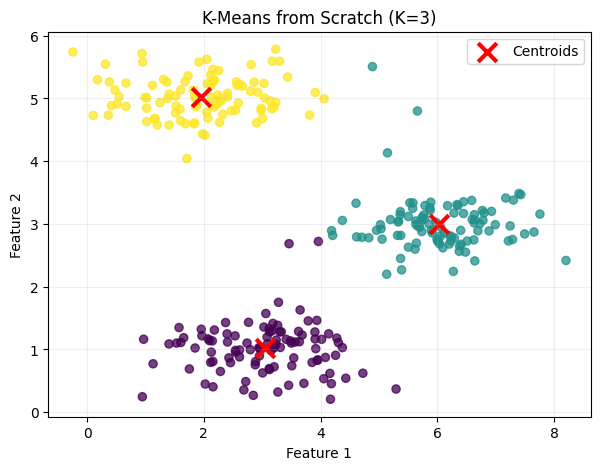

In [8]:


plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=35, alpha=0.75)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="x",
    s=180,
    linewidths=3,
    c="red",
    label="Centroids"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"K-Means from Scratch (K={K})")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Convergence

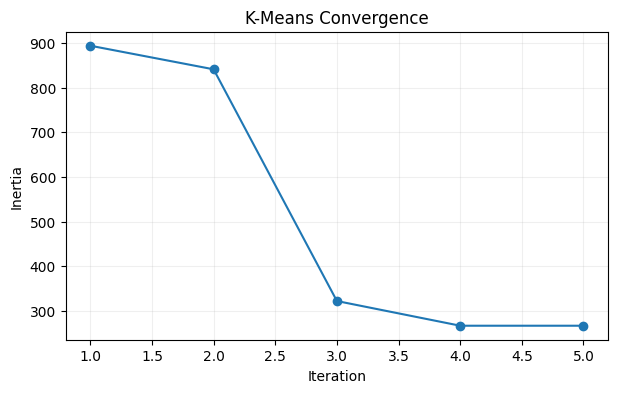

In [9]:

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(kmeans.inertia_history_) + 1), kmeans.inertia_history_, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("K-Means Convergence")
plt.grid(alpha=0.2)
plt.show()



## Elbow Method 




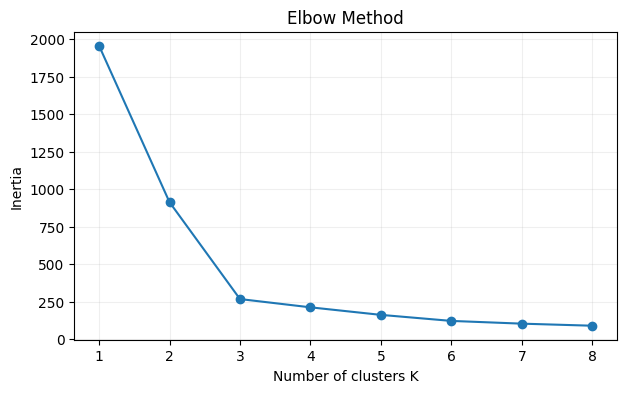

K  | Inertia       | Iterations
---|---------------|-----------
1  |     1957.6547 | 2
2  |      913.3193 | 4
3  |      266.6585 | 5
4  |      211.4822 | 10
5  |      161.1092 | 14
6  |      120.8028 | 10
7  |      102.4885 | 7
8  |       88.6813 | 7


In [10]:

k_values = range(1, 9)
inertias = []
iterations = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        max_iter=100,
        tol=1e-4,
        init="kmeans++",
        n_init=10,
        random_state=0
    ).fit(X)

    inertias.append(model.inertia_)
    iterations.append(model.n_iter_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.2)
plt.show()

print("K  | Inertia       | Iterations")
print("---|---------------|-----------")
for k, inertia, it in zip(k_values, inertias, iterations):
    print(f"{k:<2} | {inertia:13.4f} | {it}")



### Experiment 1




In [11]:

results = []

for init_method in ["random", "kmeans++"]:
    model = KMeans(
        n_clusters=3,
        max_iter=100,
        tol=1e-4,
        init=init_method,
        n_init=10,
        random_state=0
    ).fit(X)

    results.append((init_method, model.inertia_, model.n_iter_))

print("Initialization | Best inertia | Iterations")
print("----------------|---------------|------------")
for row in results:
    print(f"{row[0]:15s} | {row[1]:13.4f} | {row[2]}")


Initialization | Best inertia | Iterations
----------------|---------------|------------
random          |      266.6585 | 4
kmeans++        |      266.6585 | 5



### Experiment 2: Number of Restarts




n_init | Best inertia
-------|-------------
     1 | 266.6585
     2 | 266.6585
     5 | 266.6585
    10 | 266.6585
    20 | 266.6585


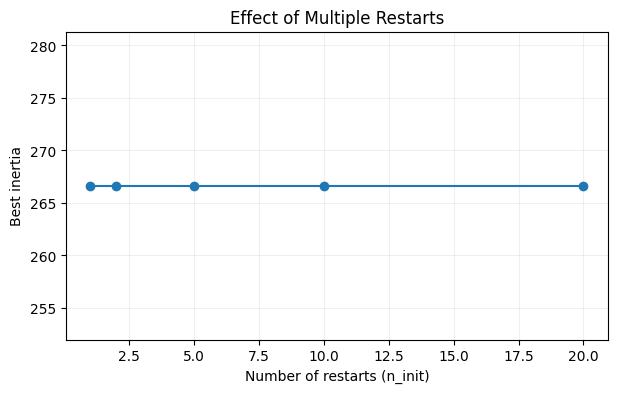

In [12]:

restart_values = [1, 2, 5, 10, 20]
restart_results = []

for n_init in restart_values:
    model = KMeans(
        n_clusters=3,
        max_iter=100,
        tol=1e-4,
        init="random",
        n_init=n_init,
        random_state=0
    ).fit(X)

    restart_results.append((n_init, model.inertia_))

print("n_init | Best inertia")
print("-------|-------------")
for n_init, inertia in restart_results:
    print(f"{n_init:6d} | {inertia:.4f}")

plt.figure(figsize=(7, 4))
plt.plot([x[0] for x in restart_results], [x[1] for x in restart_results], marker="o")
plt.xlabel("Number of restarts (n_init)")
plt.ylabel("Best inertia")
plt.title("Effect of Multiple Restarts")
plt.grid(alpha=0.2)
plt.show()



## n-D Support

In [14]:

rng = np.random.default_rng(42)

X_5d = np.vstack([
    rng.normal(loc=[0, 0, 0, 0, 0], scale=0.7, size=(120, 5)),
    rng.normal(loc=[4, 4, 4, 4, 4], scale=0.7, size=(120, 5)),
    rng.normal(loc=[0, 4, 0, 4, 0], scale=0.7, size=(120, 5))
])

model_5d = KMeans(
    n_clusters=3,
    max_iter=100,
    tol=1e-4,
    init="kmeans++",
    n_init=10,
    random_state=42
).fit(X_5d)

print("5-D dataset shape:", X_5d.shape)
print("Centroid shape:", model_5d.cluster_centers_.shape)
print("Label shape:", model_5d.labels_.shape)
print("Inertia:", model_5d.inertia_)
print("\n5-D centroids:\n", model_5d.cluster_centers_)


5-D dataset shape: (360, 5)
Centroid shape: (3, 5)
Label shape: (360,)
Inertia: 883.0739455596946

5-D centroids:
 [[-0.0352  3.8952 -0.0831  3.9539 -0.0104]
 [ 4.0494  4.0603  4.0439  3.9607  3.8215]
 [-0.0617 -0.0096  0.0253 -0.0259 -0.0197]]



## Image Compression Using K-Means


Loaded: dataset/bird_small.png
Shape of original_img: (128, 128, 3)


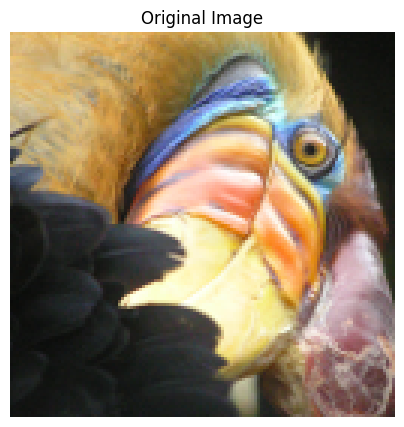

In [16]:

from PIL import Image
import os

IMAGE_PATH = "dataset/bird_small.png"

if os.path.exists(IMAGE_PATH):
    original_img = np.asarray(Image.open(IMAGE_PATH).convert("RGB"), dtype=np.float64) / 255.0
    print("Loaded:", IMAGE_PATH)
    print("Shape of original_img:", original_img.shape)

    plt.figure(figsize=(5, 5))
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
else:
    original_img = None
    print(
        "Optional image not found. To run image compression, place "
        "'bird_small.png' in the same folder as this notebook."
    )


In [17]:

if original_img is not None:
    h, w, channels = original_img.shape

   
    X_img = original_img.reshape(h * w, channels)

    print("Image dataset shape:", X_img.shape)

    image_results = {}

    for K_img in [4, 8, 16]:
        image_model = KMeans(
            n_clusters=K_img,
            max_iter=50,
            tol=1e-5,
            init="kmeans++",
            n_init=3,
            random_state=0
        ).fit(X_img)

        X_recovered = image_model.cluster_centers_[image_model.labels_]
        X_recovered = X_recovered.reshape(original_img.shape)

        image_results[K_img] = {
            "model": image_model,
            "image": X_recovered
        }

        print(
            f"K={K_img:2d} | "
            f"iterations={image_model.n_iter_:2d} | "
            f"inertia={image_model.inertia_:.4f}"
        )


Image dataset shape: (16384, 3)
K= 4 | iterations=35 | inertia=450.1308
K= 8 | iterations=42 | inertia=228.6958
K=16 | iterations=50 | inertia=117.9301


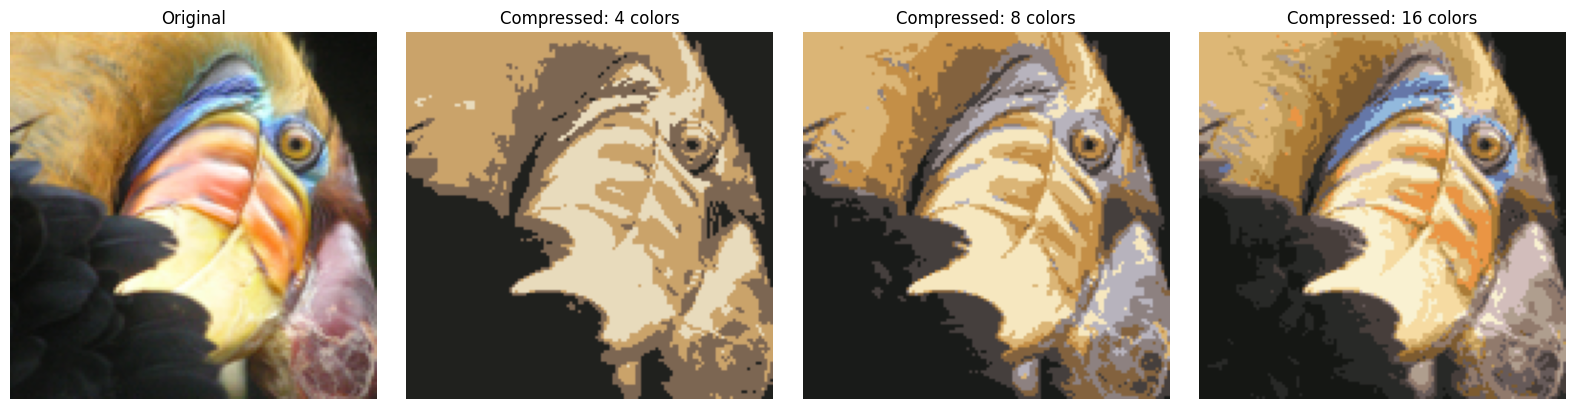

In [18]:

if original_img is not None:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(original_img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for ax, K_img in zip(axes[1:], [4, 8, 16]):
        ax.imshow(image_results[K_img]["image"])
        ax.set_title(f"Compressed: {K_img} colors")
        ax.axis("off")

    plt.tight_layout()
    plt.show()



## Image Compression Quality Experiment




In [19]:

if original_img is not None:
    print("K  | Reconstruction MSE")
    print("---|-------------------")

    for K_img in [4, 8, 16]:
        recovered = image_results[K_img]["image"]
        mse = np.mean((original_img - recovered) ** 2)
        print(f"{K_img:2d} | {mse:.8f}")
else:
    print("Run the image-loading cell after adding bird_small.png to calculate image MSE.")


K  | Reconstruction MSE
---|-------------------
 4 | 0.00915794
 8 | 0.00465283
16 | 0.00239929



## 9. Final Experimental Summary

For the report, the following points can be discussed:

| Experiment | What was changed? | What should be observed? |
|---|---|---|
| Baseline | \(K=3\), K-Means++ | Establishes the basic clustering result |
| Choice of \(K\) | \(K=1\) to \(8\) | Inertia decreases; the elbow helps choose \(K\) |
| Initialization | Random vs K-Means++ | Initialization can affect the final solution |
| Restarts | Different `n_init` values | More restarts can improve robustness |
| Dimensionality | 2-D vs 5-D | Same algorithm works with arbitrary feature dimensions |
| Image compression | \(K=4,8,16\) | More colors generally improve reconstruction quality |

### Why this is a from-scratch implementation

The clustering operations are implemented manually:
- centroid initialization,
- distance calculation,
- nearest-centroid assignment,
- centroid averaging,
- empty-cluster handling,
- convergence checking,
- inertia calculation,
- multiple restarts,
- prediction.

NumPy is used only for efficient array and mathematical operations, while the actual K-Means algorithm is written in this notebook.



## 10. Conclusion

The implemented K-Means algorithm successfully clusters both low-dimensional and higher-dimensional feature vectors without relying on `sklearn`'s K-Means implementation. The notebook also provides the requested visualizations, convergence analysis, elbow analysis, initialization experiments, and optional RGB image compression.

The experimental results can be used in the report to justify the selected value of \(K\), initialization strategy, convergence settings, and number of restarts.
